# Projet Python pour la data science

## Introduction

Les inégalités sociales de santé constituent un enjeu majeur de santé publique en France. Des travaux comme l'enquête ER 1243 de la DREES montrent que l'état de santé d'un individu est étroitement lié à son niveau de vie, son diplôme ou sa catégorie socioprofessionnelle.

**Problématique** : *Dans quelle mesure le niveau de vie détermine-t-il l'exposition aux maladies chroniques en France, et ce gradient social varie-t-il selon les pathologies et les territoires ?*

Pour répondre à cette question, ce notebook s'appuie sur les données DREES (ER 1243) disponibles sur data.gouv.fr et suit le plan suivant :

1. Récupération des données via l'API data.gouv.fr
2. Exploration et nettoyage des données
3. Visualisation des inégalités (par revenu, diplôme, territoire)
4. Modélisation : clustering des pathologies et régression pour quantifier l'effet du revenu

## 1. Import et installation des packages nécessaires

On commence par importer et installer les packages nécessaires au projet. Les packages à installer sont recensés dans le fichier requirements.txt.

In [66]:
!pip install -q -r requirements.txt

In [67]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
import geopandas as gpd
import numpy as np

In [68]:
from fonctions import calc_ratio_d10, calc_ratio_dip, plot_bivariate_metropole

**Fonctions importées depuis `fonctions.py` :**
- `calc_ratio_d10(group)` : pour un groupe de maladies, calcule le ratio du taux de chaque décile par rapport au décile 10 (référence = les 10 % les plus aisés).
- `calc_ratio_dip(group)` : même logique, mais la référence est le niveau "Supérieur" pour les analyses par diplôme.
- `plot_bivariate_metropole(gdf, col_x, col_y, label_x, label_y)` : trace une carte bivariée en croisant deux variables sur une grille 3×3 de terciles, pour la France métropolitaine.

## 2. Récupération des données

Ce projet mobilise deux sources de données complémentaires issues des **données Drees (ER 1243)**. On récupère dans un premier temps la table maladie_chronique qui contient des variables telles que le taux de prévalence et d'incidence de maladies chroniques ventilés par variables socio-démographiques. Ainsi que la table et libelles qui permet de décoder les codes des modalités présents dans les colonnes `valGroupage` et `valPartition`.

Ces données sont disponibles sur data.gouv.fr. Les données sont ensuite chargées directement via l'API de data.gouv.fr, ce qui garantit la reproductibilité du projet.

### 2.1 Utilisation de l'API data.gouv.fr

Plutôt que de télécharger manuellement les fichiers, nous utilisons l'API de data.gouv.fr pour charger les données directement dans le notebook. L'API permet d'interroger les métadonnées d'un jeu de données via son identifiant, et d'en récupérer les ressources (fichiers) associées.

La structure d'une requête est la suivante : `GET https://www.data.gouv.fr/api/1/datasets/{dataset_id}/`

On va explorer les métadonnées DREES via l'API afin de voir tous les fichiers disponibles ainsi que leurs URL et de mieux comprendre les données que l'on va charger.

In [69]:
# Identifiant du dataset DREES sur data.gouv.fr
DATASET_ID = "inegalites-sociales-face-aux-maladies-chroniques-er-1243"

# Requête sur l'API pour récupérer les métadonnées
response = requests.get(f"https://www.data.gouv.fr/api/1/datasets/{DATASET_ID}/")
metadata = response.json()

# Affichage des ressources disponibles dans ce dataset
print(f"Titre : {metadata['title']}")
print(f"\nRessources disponibles ({len(metadata['resources'])}) :")
for r in metadata['resources']:
    print(f"  - {r['title']} | format : {r['format']} | url : {r['url']}")

Titre : Inégalités sociales face aux maladies chroniques (ER 1243)

Ressources disponibles (4) :
  - er_inegalites_maladies_chroniques.csv | format : csv | url : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true
  - er_inegalites_maladies_chroniques.json | format : json | url : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/json
  - ex_analyse_maladies_chroniques.R | format : octet-stream | url : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/ex_analyse_maladies_chroniques_r
  - libelles_er1243.xlsx | format : vnd.openxmlformats-officedocument.spreadsheetml.sheet | url : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/libelles_er1243_xlsx


Maintenant, il faut extraire les URL pour pouvoir ensuite charger les données.

In [70]:
# Extraction des URLs par format
urls = {r['format']: r['url'] for r in metadata['resources']}

URL_CSV    = urls.get('csv')
URL_LABELS = urls.get('vnd.openxmlformats-officedocument.spreadsheetml.sheet')

print(f"URL CSV    : {URL_CSV}")
print(f"URL LABELS : {URL_LABELS}")

URL CSV    : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true
URL LABELS : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/libelles_er1243_xlsx


### 2.2 Chargement du dataset principal sur les maladies chroniques

In [71]:
print("Chargement du dataset maladies chroniques")
df_maladies = pd.read_csv(URL_CSV, sep=";", low_memory=False)

print(f"Dataset chargé : {df_maladies.shape[0]} lignes × {df_maladies.shape[1]} colonnes")
df_maladies.head()

Chargement du dataset maladies chroniques
Dataset chargé : 46176 lignes × 20 colonnes


,type,varTaux,varTauxLib,I_cat,cat,catLib,varPartition,valPartition,varGroupage,valGroupage,varPoids,poids1,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH
0,incidence,TOP_CVIC_CHR,Insuffisance cardiaque chronique,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,30116.961505,6.302392e+06,0.004779,0.004779,0.004521,0.005037,0.004779,0.004521,0.005037
1,incidence,TOP_PRETARD_IND,Déficience mentale,0,SUP_PSYPAT_CAT,Maladies psychiatriques,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,1309.430271,6.349002e+06,0.000206,0.000206,0.000150,0.000263,0.000206,0.000150,0.000263
2,incidence,TOP_RTRANS_CHR,Suivi de transplantation rénale,0,SUP_RIRCT_CAT,Insuffisance rénale chronique terminale,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,1,POIDS_FIDELI_S,0.000000,5.294220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,incidence,TOP_CVTRRYC_IND,Troubles du rythme ou de la conduction cardiaque,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,6959.005587,6.266976e+05,0.011104,0.011745,0.010400,0.013090,0.011888,0.010576,0.013201
4,incidence,TOP_IRHEMOP_IND,Hémophilie ou troubles de l'hémostase graves,0,SUP_INFRARVIH_CAT,Maladies inflammatoires ou rares ou VIH ou SIDA,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,92.865604,6.438119e+05,0.000144,0.000147,-0.000005,0.000300,0.000154,-0.000004,0.000312


### 2.3 Chargement du fichier de libellés

Le fichier `libelles_er1243.xlsx` fourni par la DREES permet de décoder les codes des modalités présents dans les colonnes `valGroupage` et `valPartition`.
Par exemple, le code `"1"` pour le décile de revenu correspond à "20% les plus modestes".

In [72]:
print("Chargement du fichier de libellés...")
response_libelles = requests.get(URL_LABELS)
libelles = pd.read_excel(BytesIO(response_libelles.content))

print(f"Libellés chargés : {libelles.shape[0]} lignes × {libelles.shape[1]} colonnes")
libelles.head(10)

Chargement du fichier de libellés...


Libellés chargés : 54 lignes × 3 colonnes


,var,moda,moda_lib
0,EAR_DIPLR_S,NaN,NaN
1,EAR_DIPLR_S,1,Pas de diplôme
2,EAR_DIPLR_S,2,BEP/CAP
3,EAR_DIPLR_S,3,Baccalauréat
4,EAR_DIPLR_S,4,Enseignement supérieur
5,EAR_GS_S,1,Agriculteurs exploitants
6,EAR_GS_S,2,"Artisans, commerçants, chefs d'entreprise"
7,EAR_GS_S,3,Cadres et professions intellectuelles supérieures
8,EAR_GS_S,4,Professions intermédiaires
9,EAR_GS_S,5,Employés


### 2.4 Vérification du chargement

Avant tout nettoyage, on vérifie que nos données sont bien chargées et cohérentes.

In [73]:
sources = {
    "DREES - Maladies chroniques" : df_maladies,
    "DREES - Libellés"           : libelles
}

for nom, dataframe in sources.items():
    print(f"{nom}")
    print(f"  → {dataframe.shape[0]} lignes × {dataframe.shape[1]} colonnes")
    print(f"  → Valeurs manquantes : {dataframe.isnull().sum().sum()}")
    print()

DREES - Maladies chroniques
  → 46176 lignes × 20 colonnes
  → Valeurs manquantes : 10738

DREES - Libellés
  → 54 lignes × 3 colonnes
  → Valeurs manquantes : 2



## 3. Exploration préalable des données

Avant tout nettoyage ou analyse, on explore la structure et le contenu des trois sources chargées afin de :
- comprendre l'organisation des données
- identifier les variables utiles pour répondre à la problématique
- repérer d'éventuels problèmes (valeurs manquantes, types incorrects, doublons)

### 3.1 Exploration du dataset maladies_chroniques

Commençons par regarder la structure générale du dataset maladies_chroniques (df_maladies). 

#### 3.1.1 Structure générale du dataset

On va dans un premier temps s'intéresser aux dimensions du dataset (nombre de lignes et colonnes) ainsi qu'au type des variables.

In [74]:
# Dimensions et types
print(f"Le contient {df_maladies.shape[0]} lignes (observations) et {df_maladies.shape[1]} colonnes (variables).")
print("Types des colonnes :")
print(df_maladies.dtypes)

Le contient 46176 lignes (observations) et 20 colonnes (variables).
Types des colonnes :
type                  object
varTaux               object
varTauxLib            object
I_cat                  int64
cat                   object
catLib                object
varPartition          object
valPartition          object
varGroupage           object
valGroupage           object
varPoids              object
poids1               float64
poidsTot             float64
txNonStand           float64
txStandDir           float64
txStandDirModBB      float64
txStandDirModBH      float64
txStandIndir         float64
txStandIndirModBB    float64
txStandIndirModBH    float64
dtype: object


In [75]:
n_numeriques = df_maladies.select_dtypes(include='number').shape[1]
n_categorielles = df_maladies.select_dtypes(include='object').shape[1]
print(f"Variables numériques : {n_numeriques}\n")
print(f"Variables catégorielles : {n_categorielles}\n")

Variables numériques : 10

Variables catégorielles : 10



#### 3.1.2 Statistiques descriptives sur les variables numériques

Maintenant que l'on connait le type des colonnes, intéressons nous plus particulièrement aux variables numériques et vérifions notamment que les ordres de grandeur de ces variables sont cohérents avec ce qui est attendu (par exemple, un taux doit être compris entre 0 et 1).

In [76]:
# Statistiques descriptives des colonnes numériques
df_maladies.describe()

,I_cat,poids1,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH
count,46176.000000,4.617200e+04,4.617200e+04,46172.000000,46172.000000,46172.000000,46172.000000,45794.000000,45794.000000,45794.000000
mean,0.211538,4.084664e+04,3.306689e+06,0.015083,0.014951,0.013526,0.016377,0.014984,0.013608,0.016359
std,0.408404,1.788971e+05,5.607415e+06,0.037744,0.037236,0.035579,0.039294,0.037206,0.035653,0.039123
min,0.000000,0.000000e+00,4.365972e+02,0.000000,0.000000,-0.046276,0.000000,0.000000,-0.057530,0.000000
25%,0.000000,3.513649e+02,3.640001e+05,0.000570,0.000576,0.000209,0.000841,0.000598,0.000244,0.000869
50%,0.000000,2.614705e+03,9.753148e+05,0.002697,0.002720,0.001930,0.003485,0.002767,0.001986,0.003504
75%,0.000000,1.636898e+04,3.640875e+06,0.011545,0.011624,0.009733,0.013296,0.011734,0.009851,0.013414
max,1.000000,6.070514e+06,4.773171e+07,0.588601,0.588512,0.580976,0.678644,0.590223,0.580827,0.708820


#### 3.1.3 Valeurs manquantes

Maintenant il est temps de s'intéresser à un point essentiel dont il faudra tenir compte dans la suite de notre projet, les valeurs manquantes.

In [77]:
# Valeurs manquantes par colonne
missing = df_maladies.isnull().sum()
missing_pct = (missing / len(df_maladies) * 100).round(2)

missing_df = pd.DataFrame({
    'nb_manquants': missing,
    'pct_manquants': missing_pct
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print(f"{len(missing_df)} colonnes contiennent des valeurs manquantes :\n")
print(missing_df)

13 colonnes contiennent des valeurs manquantes :

                   nb_manquants  pct_manquants
varPartition               3016           6.53
valPartition               3016           6.53
varGroupage                1768           3.83
valGroupage                1768           3.83
txStandIndirModBB           382           0.83
txStandIndir                382           0.83
txStandIndirModBH           382           0.83
poids1                        4           0.01
poidsTot                      4           0.01
txStandDirModBB               4           0.01
txStandDir                    4           0.01
txNonStand                    4           0.01
txStandDirModBH               4           0.01


#### 3.1.4 Variables d'intérêt

Le dataset est structuré autour de trois axes principaux :
- **`type`** : prévalence ou incidence
- **`varGroupage` / `valGroupage`** : la variable de ventilation et sa modalité (ex. décile de revenu, CSP, diplôme...)
- **`varPartition` / `valPartition`** : une éventuelle partition supplémentaire par région ou par sexe

Ces variables nous seront particulièrement utiles pour la suite.

In [78]:
# Valeurs uniques des variables de structure
print("=== type ===")
print(df_maladies['type'].value_counts())

print("\n=== varGroupage (variables de ventilation disponibles) ===")
print(df_maladies['varGroupage'].value_counts())

print("\n=== varPartition ===")
print(df_maladies['varPartition'].value_counts())

=== type ===
type
incidence     23088
prevalence    23088
Name: count, dtype: int64

=== varGroupage (variables de ventilation disponibles) ===
varGroupage
FISC_NIVVIEM_E2015_S_moy_10    20800
classeAge10                    16640
SEXE                            3536
EAR_GS_S                        2184
EAR_DIPLR_S                     1248
Name: count, dtype: int64

=== varPartition ===
varPartition
FISC_REG_S    37128
SEXE           6032
Name: count, dtype: int64


In [79]:
# Nombre de maladies distinctes dans le dataset
print(f"Nombre de maladies/pathologies distinctes : {df_maladies['varTauxLib'].nunique()}")
print("\nListe des pathologies :")
print(df_maladies['varTauxLib'].unique())

Nombre de maladies/pathologies distinctes : 52

Liste des pathologies :
['Insuffisance cardiaque chronique' 'Déficience mentale'
 'Suivi de transplantation rénale'
 'Troubles du rythme ou de la conduction cardiaque'
 "Hémophilie ou troubles de l'hémostase graves"
 'Maladie coronaire chronique'
 'Maladies inflammatoires chroniques intestinales' 'Cancers'
 'Traitements antihypertenseurs'
 'Polyarthrite rhumatoïde et maladies apparentées' 'Épilepsie'
 'Traitements neuroleptiques'
 'Artériopathie oblitérante du membre inférieur' 'Syndrome coronaire aigu'
 'Maladies métaboliques héréditaires ou amylose' 'VIH ou SIDA'
 'Maladies psychiatriques' 'Maladie valvulaire'
 'Traitements hypolipémiants' 'Autres affections neurologiques'
 'Troubles addictifs' 'Maladies du foie ou du pancréas'
 'Insuffisance cardiaque aiguë' 'Insuffisance rénale chronique terminale'
 'Myopathie ou myasthénie' 'Maladie de Parkinson'
 "Traitements antidépresseurs ou régulateurs de l'humeur"
 'Troubles psychotiques' 'Trai

On examine la distribution du taux de prévalence standardisé direct (`txStandDir`) pour avoir une idée de l'ordre de grandeur des valeurs et repérer d'éventuelles valeurs aberrantes.

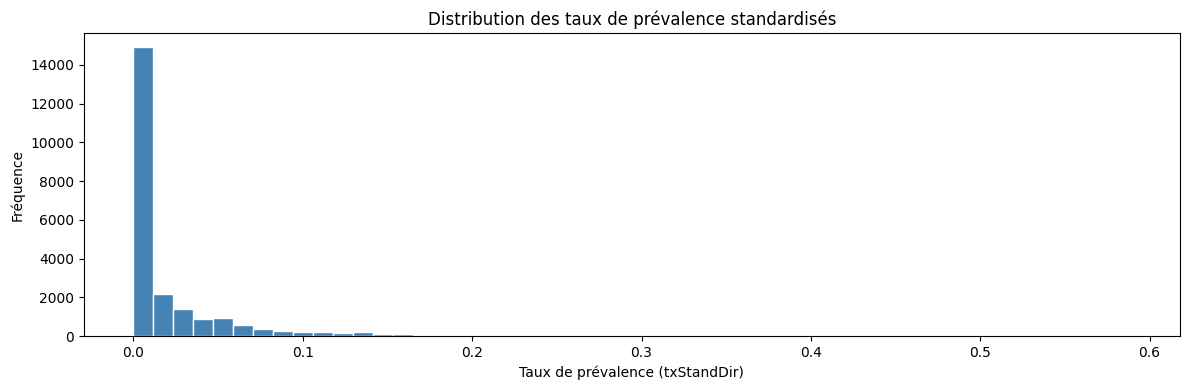


Min : 0.0000
Max : 0.5885
Médiane : 0.0049


In [80]:
prevalences = df_maladies[df_maladies['type'] == 'prevalence']['txStandDir'].dropna()

fig, ax = plt.subplots(figsize=(12, 4))

# Histogramme
ax.hist(prevalences, bins=50, color='steelblue', edgecolor='white')
ax.set_title("Distribution des taux de prévalence standardisés")
ax.set_xlabel("Taux de prévalence (txStandDir)")
ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

print(f"\nMin : {prevalences.min():.4f}")
print(f"Max : {prevalences.max():.4f}")
print(f"Médiane : {prevalences.median():.4f}")

#### 3.1.5 Variables de catégorie : `catLib` et `I_cat`

Le dataset contient deux variables de regroupement des pathologies qui seront utilisées dans les analyses suivantes :
- `catLib` : libellé de la grande catégorie de maladie (ex. "Maladies cardioneurovasculaires")
- `I_cat` : indicateur binaire valant `1` lorsque la ligne correspond à une **grande catégorie agrégée** (et non à une pathologie fine). On filtre sur `I_cat == 1` pour travailler au niveau des catégories.

On vérifie leur contenu ci-dessous.

In [81]:
# Vérification des variables de catégorie
print("=== I_cat (0 = pathologie fine, 1 = catégorie agrégée) ===")
print(df_maladies['I_cat'].value_counts())

print("\n=== catLib (grandes catégories disponibles) ===")
print(df_maladies['catLib'].value_counts())

=== I_cat (0 = pathologie fine, 1 = catégorie agrégée) ===
I_cat
0    36408
1     9768
Name: count, dtype: int64

=== catLib (grandes catégories disponibles) ===
catLib
Maladies cardioneurovasculaires                    10656
Maladies inflammatoires ou rares ou VIH ou SIDA     7992
Maladies neurologiques ou dégénératives             7104
Maladies psychiatriques                             6216
Traitements psychotropes                            4440
Insuffisance rénale chronique terminale             3552
Traitements du risque vasculaire                    2664
Cancers                                              888
Maladies du foie ou du pancréas                      888
Maladies respiratoires chroniques                    888
Diabète                                              888
Name: count, dtype: int64


### 3.2 Exploration du fichier de libellés

#### 3.2.1 Structure générale

On vérifie la structure du fichier de libellés afin de préparer la jointure avec le dataset principal.

In [82]:
# Dimensions et types
print(f"Dimensions : {libelles.shape[0]} lignes × {libelles.shape[1]} colonnes\n")
print("Types des colonnes :")
print(libelles.dtypes)
libelles.head(5)

Dimensions : 54 lignes × 3 colonnes

Types des colonnes :
var         object
moda        object
moda_lib    object
dtype: object


,var,moda,moda_lib
0,EAR_DIPLR_S,NaN,NaN
1,EAR_DIPLR_S,1,Pas de diplôme
2,EAR_DIPLR_S,2,BEP/CAP
3,EAR_DIPLR_S,3,Baccalauréat
4,EAR_DIPLR_S,4,Enseignement supérieur


In [83]:
n_numeriques_libelles = libelles.select_dtypes(include='number').shape[1]
n_categorielles_libelles = libelles.select_dtypes(include='object').shape[1]
print(f"Variables numériques : {n_numeriques_libelles}\n")
print(f"Variables catégorielles : {n_categorielles_libelles}\n")

Variables numériques : 0

Variables catégorielles : 3



#### 3.2.2 Toutes les modalités du datasat principal ont-elles un libellé ?

In [84]:
# Vérification : toutes les modalités du dataset principal ont-elles un libellé ?
modalites_maladies = df_maladies['varGroupage'].unique()
modalites_libelles = libelles.iloc[:, 0].unique()  # à ajuster selon le nom de colonne réel

non_couverts = [m for m in modalites_maladies if m not in modalites_libelles]
print(f"Modalités sans libellé : {non_couverts}")

Modalités sans libellé : [nan]


#### 3.2.3 Valeurs manquantes

In [85]:
# Valeurs manquantes par colonne
missing_libelles = libelles.isnull().sum()
missing_pct_libelles = (missing_libelles / len(libelles) * 100).round(2)

missing_libelles = pd.DataFrame({
    'nb_manquants': missing_libelles,
    'pct_manquants': missing_pct_libelles
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print(f"{len(missing_libelles)} colonnes contiennent des valeurs manquantes :\n")
print(missing_libelles)

2 colonnes contiennent des valeurs manquantes :

          nb_manquants  pct_manquants
moda                 1           1.85
moda_lib             1           1.85


### 3.3 Résumé de l'exploration

| Source | Lignes (observations) | Colonnes (variables) | Valeurs manquantes | Points d'attention | 
|---|---|---|---|---|
| DREES principal | 46176 | 20 (10 variables numériques et 10 varibles catégorielles) | 13 variables avec des valeurs manquantes | Taux manquants sur effectifs faibles |
| Libellés DREES | 54 | 3 (toutes catégorielles) | 2 variables avec des valeurs manquantes | À joindre sur varGroupage/valGroupage |

On va donc pouvoir passer au nettoyage et à la structuration des données.

## 4. Nettoyage et structuration des données

L'exploration a révélé plusieurs points à traiter avant l'analyse :

- Des **valeurs manquantes** sur 13 colonnes de `df` (essentiellement les bornes d'intervalles de confiance et certains taux)
- Le fichier de **libellés** doit être joint au dataset principal pour décoder `valGroupage`
- La variable `valGroupage` est de type `object` alors qu'elle doit être **numérique** pour les déciles
- Des colonnes inutiles pour l'analyse peuvent être **exclues** pour alléger le dataset

### 4.1 Traitement des valeurs manquantes

Les valeurs manquantes se concentrent sur les colonnes d'intervalles de confiance (`txStandDirModBB`, `txStandDirModBH`, etc.) et certains taux. Ces colonnes sont absentes uniquement pour les strates à faibles effectifs : la DREES ne publie pas de taux non fiables statistiquement.

Stratégie :
- On **conserve** toutes les lignes : supprimer les lignes avec NaN ferait perdre des strates entières.
- Dans les analyses qui requièrent un taux non manquant (`txStandDir`), on appliquera un `.dropna()` local.
- Les colonnes d'intervalles de confiance manquantes seront ignorées dans les agrégations mais utilisées quand disponibles pour les graphiques.

In [86]:
# Résumé des valeurs manquantes avant nettoyage
missing_avant = df_maladies.isnull().sum()
print("Valeurs manquantes par colonne (avant nettoyage) :")
print(missing_avant[missing_avant > 0].sort_values(ascending=False))
print(f"\nTotal lignes : {len(df_maladies)} | Lignes sans aucun NaN : {df_maladies.dropna().shape[0]}")

Valeurs manquantes par colonne (avant nettoyage) :
varPartition         3016
valPartition         3016
varGroupage          1768
valGroupage          1768
txStandIndirModBB     382
txStandIndir          382
txStandIndirModBH     382
poids1                  4
poidsTot                4
txStandDirModBB         4
txStandDir              4
txNonStand              4
txStandDirModBH         4
dtype: int64

Total lignes : 46176 | Lignes sans aucun NaN : 41028


### 4.2 Jointure avec le fichier de libellés

On enrichit le dataset principal avec les libellés lisibles des modalités de `valGroupage`. La clé de jointure est `(varGroupage, valGroupage)`.

In [87]:
# Renommage des colonnes du fichier libellés pour la jointure
libelles.columns = ['varGroupage', 'valGroupage', 'libelle']

# Harmonisation des types (les deux colonnes doivent être des strings)
libelles['varGroupage'] = libelles['varGroupage'].astype(str).str.strip()
libelles['valGroupage'] = libelles['valGroupage'].astype(str).str.strip()
df_maladies['varGroupage']     = df_maladies['varGroupage'].astype(str).str.strip()
df_maladies['valGroupage']     = df_maladies['valGroupage'].astype(str).str.strip()

# Jointure
df_maladies = df_maladies.merge(libelles, on=['varGroupage', 'valGroupage'], how='left')

# Vérification
n_non_joints = df_maladies['libelle'].isnull().sum()
print(f"Lignes sans libellé après jointure : {n_non_joints} ({n_non_joints/len(df_maladies)*100:.1f} %)")
df_maladies[['varGroupage', 'valGroupage', 'libelle']].drop_duplicates().head(10)

Lignes sans libellé après jointure : 3848 (8.3 %)


,varGroupage,valGroupage,libelle
0,nan,nan,NaN
2,FISC_NIVVIEM_E2015_S_moy_10,1,Dixième le plus modeste de la population
3,FISC_NIVVIEM_E2015_S_moy_10,2,Deuxième dixième le plus modeste de la population
5,FISC_NIVVIEM_E2015_S_moy_10,3,Troisième dixième le plus modeste de la popula...
7,FISC_NIVVIEM_E2015_S_moy_10,4,Quatrième dixième le plus modeste de la popula...
13,FISC_NIVVIEM_E2015_S_moy_10,5,Cinquième dixième le plus modeste de la popula...
18,FISC_NIVVIEM_E2015_S_moy_10,6,Cinquième dixième le plus aisé de la population
24,FISC_NIVVIEM_E2015_S_moy_10,7,Quatrième dixième le plus aisé de la population
26,FISC_NIVVIEM_E2015_S_moy_10,8,Troisième dixième le plus aisé de la population
27,FISC_NIVVIEM_E2015_S_moy_10,10,Dixième le plus aisé de la population


### 4.3 Correction des types

La colonne `valGroupage` contient des valeurs mixtes (déciles numériques et modalités textuelles). On crée une colonne `valGroupage_num` pour les analyses quantitatives.

In [88]:
# Création d'une colonne numérique pour valGroupage (utilisée pour les déciles)
df_maladies['valGroupage_num'] = pd.to_numeric(df_maladies['valGroupage'], errors='coerce')

# Vérification : combien de lignes sont convertibles ?
n_num = df_maladies['valGroupage_num'].notna().sum()
print(f"Lignes avec valGroupage numérique : {n_num} / {len(df_maladies)} ({n_num/len(df_maladies)*100:.1f} %)")

Lignes avec valGroupage numérique : 24232 / 46176 (52.5 %)


### 4.4 Résumé post-nettoyage

In [89]:
print("=== Dataset principal après nettoyage ===")
print(f"Dimensions       : {df_maladies.shape[0]} lignes × {df_maladies.shape[1]} colonnes")
print("Nouvelles colonnes ajoutées : 'libelle', 'valGroupage_num'")
print(f"Valeurs manquantes (txStandDir) : {df_maladies['txStandDir'].isnull().sum()} lignes")
df_maladies.head(3)

=== Dataset principal après nettoyage ===
Dimensions       : 46176 lignes × 22 colonnes
Nouvelles colonnes ajoutées : 'libelle', 'valGroupage_num'
Valeurs manquantes (txStandDir) : 4 lignes


,type,varTaux,varTauxLib,I_cat,cat,catLib,varPartition,valPartition,varGroupage,valGroupage,...,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH,libelle,valGroupage_num
0,incidence,TOP_CVIC_CHR,Insuffisance cardiaque chronique,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,nan,nan,...,6.302392e+06,0.004779,0.004779,0.004521,0.005037,0.004779,0.004521,0.005037,NaN,NaN
1,incidence,TOP_PRETARD_IND,Déficience mentale,0,SUP_PSYPAT_CAT,Maladies psychiatriques,FISC_REG_S,28,nan,nan,...,6.349002e+06,0.000206,0.000206,0.000150,0.000263,0.000206,0.000150,0.000263,NaN,NaN
2,incidence,TOP_RTRANS_CHR,Suivi de transplantation rénale,0,SUP_RIRCT_CAT,Insuffisance rénale chronique terminale,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,1,...,5.294220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Dixième le plus modeste de la population,1.0


## 5. Visualisation 

### 5.1 Taux de prévalence selon l'âge

Nous cherchons dans un premier temps à visuliser s'il y a des différences de taux de maladies chroniques entre les différents niveaux de vie. 

Pour commencer, voyons tout d'abord la proportion de ces maladies en fonction de l'âge.

In [90]:
df_age_bis = df_maladies[(df_maladies['type'] == 'prevalence') & 
            (df_maladies['varGroupage'] == 'classeAge10') & 
            (df_maladies['varPartition'].isna()) &
            (df_maladies['catLib'] == 'Maladies cardioneurovasculaires')].copy()

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']

df_age_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)

df_age_bis = df_age_bis.sort_values('valGroupage')

Maintenant, que l'on a notre tableau de données, on va tracer l'histogrammes.

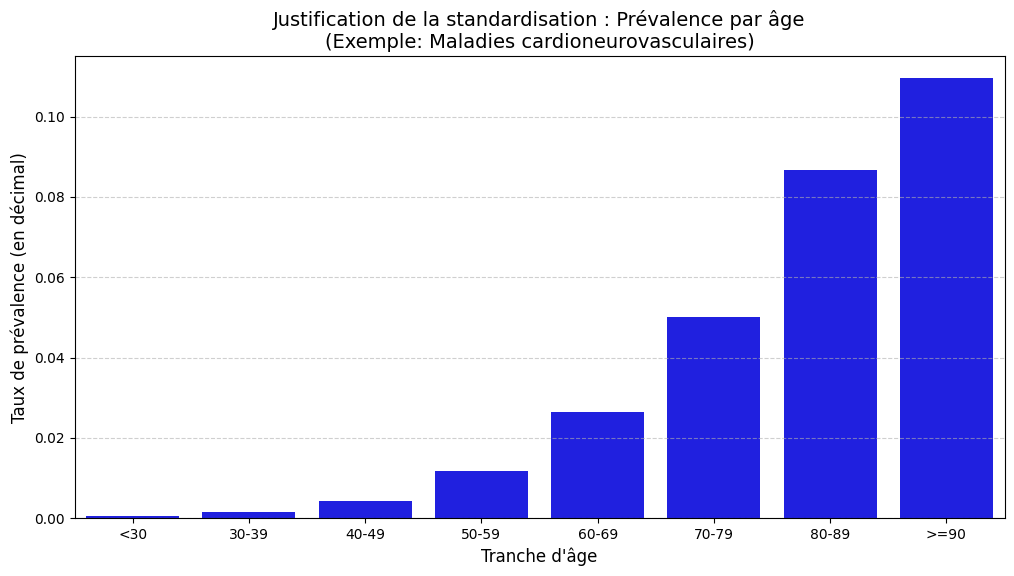

In [91]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_age_bis, x='valGroupage', y='txNonStand', color="blue", order=ordre_age, errorbar=None)

plt.title("Justification de la standardisation : Prévalence par âge\n(Exemple: Maladies cardioneurovasculaires)", fontsize=14)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.ylabel("Taux de prévalence (en décimal)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()

On remarque directement que comme prévu, l'âge est un facteur déterminent dans cette étude. On remarque à l'aide de ce graphique que le taux de prévalence explose avec l'âge. Afin de mener une étude sur les critères sociaux et non sur l'âge nous allons essayer d'effacer ce facteur. 

Pour cela la base de données dispose de données stadardisé par rapport à l'âge, voyons à quoi cela ressemble et si elle efface bien l'effet de l'âge.

In [92]:
df_age_bis = df_maladies[
    (df_maladies['type'] == 'prevalence') & 
    (df_maladies['varGroupage'] == 'classeAge10') & 
    (df_maladies['varPartition'].isna()) &
    (df_maladies['varTauxLib'] == 'Maladies cardioneurovasculaires') # On prend le TOTAL uniquement
].copy()

df_age_bis = df_age_bis.dropna(subset=['valGroupage', 'txStandDir'])

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']
df_age_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)
df_age_bis = df_age_bis.sort_values('valGroupage')

erreur_inf = df_age_bis['txStandDir'] - df_age_bis['txStandDirModBB']
erreur_sup = df_age_bis['txStandDirModBH'] - df_age_bis['txStandDir']
erreurs = [erreur_inf, erreur_sup]

On passe maintenant à la représentation.

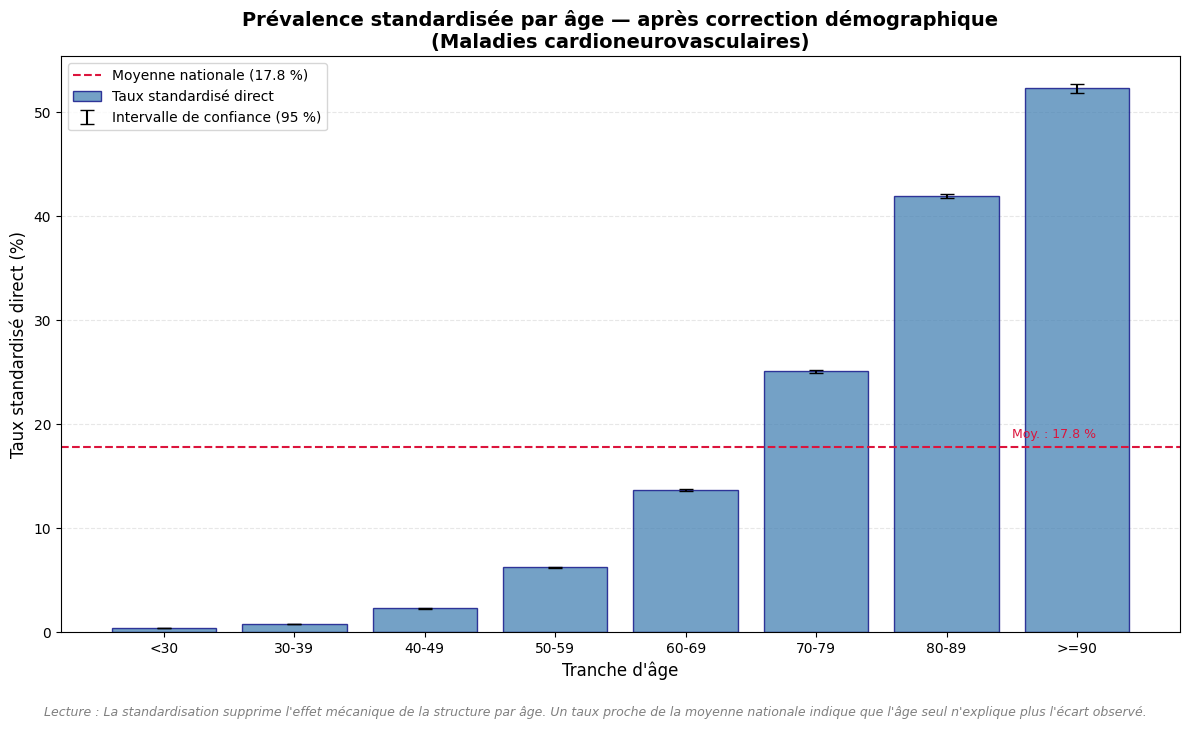

In [93]:
# Valeur de référence : moyenne nationale tous âges confondus
ref_nationale = df_age_bis['txStandDir'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    df_age_bis['valGroupage'].astype(str),
    df_age_bis['txStandDir'] * 100,     # Conversion en %
    color='steelblue', edgecolor='navy', alpha=0.75,
    label='Taux standardisé direct'
)

# Intervalles de confiance (convertis en %)
ax.errorbar(
    x=df_age_bis['valGroupage'].astype(str),
    y=df_age_bis['txStandDir'] * 100,
    yerr=[erreur_inf * 100, erreur_sup * 100],
    fmt='none', ecolor='black', capsize=5,
    label='Intervalle de confiance (95 %)'
)

# Ligne de référence : moyenne nationale
ax.axhline(
    ref_nationale, color='crimson', linestyle='--', linewidth=1.5,
    label=f'Moyenne nationale ({ref_nationale:.1f} %)'
)

# Annotation de la ligne de référence
ax.text(
    len(ordre_age) - 1.5, ref_nationale * 1.03,
    f'Moy. : {ref_nationale:.1f} %',
    color='crimson', fontsize=9, va='bottom'
)

ax.set_title(
    "Prévalence standardisée par âge — après correction démographique\n"
    "(Maladies cardioneurovasculaires)",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel("Tranche d'âge", fontsize=12)
ax.set_ylabel("Taux standardisé direct (%)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

# Note de lecture intégrée dans la figure
fig.text(
    0.5, -0.03,
    "Lecture : La standardisation supprime l'effet mécanique de la structure par âge. "
    "Un taux proche de la moyenne nationale indique que l'âge seul n'explique plus l'écart observé.",
    ha='center', fontsize=9, style='italic', color='gray'
)

plt.tight_layout()
plt.show()

### 5.2 Inégalités d'incidence par grandes catégories (Modestes vs Aisés)

Ce bloc calcule le ratio d'incidence entre les 10 % les plus modestes (Décile 1) et les 10 % les plus aisés (Décile 10). Un ratio supérieur à 1 signifie que les plus modestes développent davantage la pathologie que les plus aisés.

Le tableau ci-dessous présente ces ratios par catégorie de maladie, suivi d'un graphique pour en faciliter la comparaison visuelle.

Ce bloc calcule le ratio d'incidence entre les 10 % les plus modestes (Décile 1) et les 10 % les plus aisés (Décile 10).

Inégalités d'incidence : Ratio Modestes (D1) / Aisés (D10)


valGroupage,Ratio_D1_D10
catLib,
Diabète,2.786879
Insuffisance rénale chronique terminale,2.760562
Maladies du foie ou du pancréas,2.196438
Maladies psychiatriques,1.954073
Maladies respiratoires chroniques,1.575937
Maladies neurologiques ou dégénératives,1.494638
Maladies cardioneurovasculaires,1.357041
Maladies inflammatoires ou rares ou VIH ou SIDA,1.151304
Traitements du risque vasculaire,1.096190


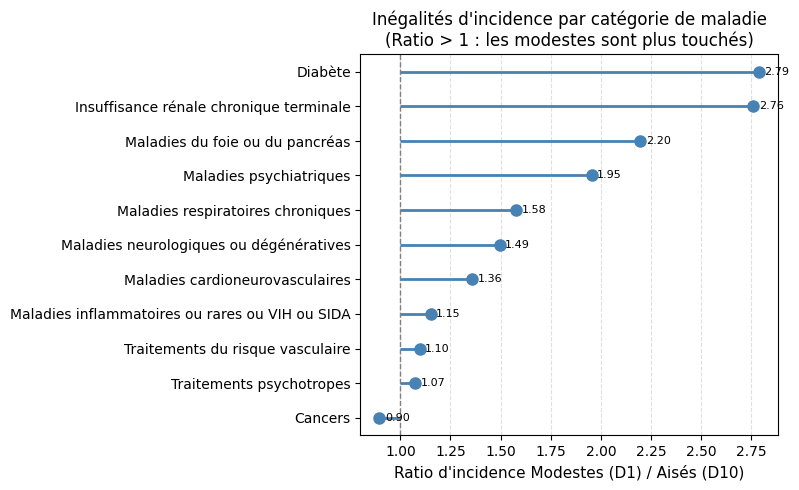

In [94]:
mask_inc = (df_maladies['I_cat'] == 1) & (df_maladies['varPartition'].isna()) & \
           (df_maladies['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') & \
           (df_maladies['type'] == 'incidence')

df_inc = df_maladies[mask_inc].copy()
# Conversion de la colonne des déciles en numérique
df_inc['valGroupage'] = pd.to_numeric(df_inc['valGroupage'], errors='coerce')

# Calcul du ratio D1 / D10
pivot_inc = df_inc.pivot_table(index='catLib', columns='valGroupage', values='txStandDir')
pivot_inc['Ratio_D1_D10'] = pivot_inc[1] / pivot_inc[10]

print("Inégalités d'incidence : Ratio Modestes (D1) / Aisés (D10)")
display(pivot_inc[['Ratio_D1_D10']].sort_values(by='Ratio_D1_D10', ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
data_plot = pivot_inc[['Ratio_D1_D10']].sort_values('Ratio_D1_D10')

ax.hlines(data_plot.index, 1, data_plot['Ratio_D1_D10'], color='steelblue', linewidth=2)
ax.plot(data_plot['Ratio_D1_D10'], data_plot.index, 'o', color='steelblue', markersize=8)
ax.axvline(1, linestyle='--', color='gray', linewidth=1)  # référence parité

for _, row in data_plot.iterrows():
    ax.annotate(f"{row['Ratio_D1_D10']:.2f}", xy=(row['Ratio_D1_D10'], _),
                xytext=(4, 0), textcoords='offset points', fontsize=8, va='center')

ax.set_xlabel("Ratio d'incidence Modestes (D1) / Aisés (D10)", fontsize=11)
ax.set_title("Inégalités d'incidence par catégorie de maladie\n(Ratio > 1 : les modestes sont plus touchés)", fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Les pathologies à ratio le plus élevé seront celles pour lesquelles le gradient social est le plus marqué. Elles feront l'objet d'une analyse plus fine dans la section 5.3, où l'on décomposera ce gradient décile par décile.

### 5.3 Évolution du ratio d'incidence selon le décile de niveau de vie

Pour chaque catégorie de maladie, on calcule le ratio entre le taux d'incidence de chaque décile et celui du 10ème décile (les 10 % les plus aisés), pris comme référence.

Ce choix de normalisation permet de s'affranchir des différences de prévalence absolue entre pathologies (une maladie rare et une maladie fréquente ne sont pas comparables en valeur brute) et de concentrer la lecture sur la **forme du gradient social**.

Un gradient social net se manifeste par une courbe **décroissante de gauche à droite** : plus le décile est faible (revenu modeste), plus le ratio est élevé. Une courbe plate autour de 1 signale une pathologie socialement indifférenciée.

Ce bloc crée des graphiques en ligne (un par catégorie de maladie) montrant l'évolution du taux par rapport au 10ème décile.

/tmp/ipykernel_4220/4003961223.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_inc_ratio = df_inc.groupby('catLib', group_keys=False).apply(calc_ratio_d10)


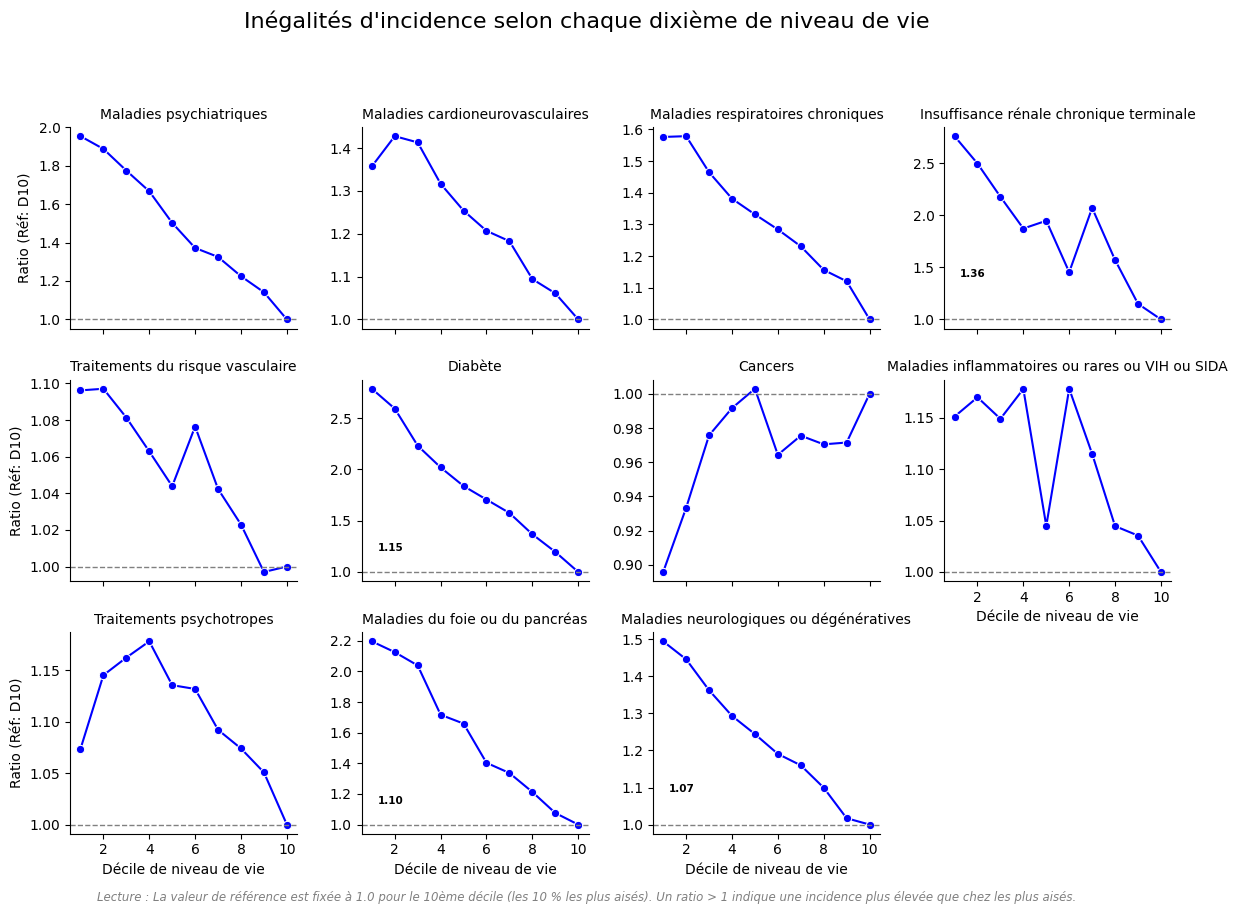

In [95]:
df_inc_ratio = df_inc.groupby('catLib', group_keys=False).apply(calc_ratio_d10)

# Visualisation 
g = sns.FacetGrid(df_inc_ratio, col="catLib", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "valGroupage", "ratio_to_D10", marker="o", color="blue")
g.set_axis_labels("Décile de niveau de vie", "Ratio (Réf: D10)")
g.set_titles(col_template="{col_name}")

g.refline(y=1, linestyle="--", color="gray", linewidth=1)  # ← ligne de référence à y=1

# Annotation de la valeur du ratio au décile 1 sur chaque facette
for ax, (catlib, group) in zip(g.axes.flat, df_inc_ratio.groupby("catLib")):
    val = group.loc[group["valGroupage"] == 1, "ratio_to_D10"]
    if not val.empty:
        ax.annotate(f"{val.values[0]:.2f}", xy=(1, val.values[0]),
                    xytext=(4, 4), textcoords="offset points", fontsize=7.5, fontweight="bold")

g.fig.suptitle("Inégalités d'incidence selon chaque dixième de niveau de vie", fontsize=16)

# ← Note de lecture intégrée dans la figure (remplace la cellule Markdown suivante)
g.fig.text(
    0.5, -0.01,
    "Lecture : La valeur de référence est fixée à 1.0 pour le 10ème décile (les 10 % les plus aisés). "
    "Un ratio > 1 indique une incidence plus élevée que chez les plus aisés.",
    ha="center", fontsize=8.5, style="italic", color="gray"
)

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Inégalités d'incidence selon chaque dixième de niveau de vie", fontsize=16)
plt.show()

Les courbes révèlent une hétérogénéité importante entre pathologies :

- Les **maladies à fort gradient** touchent disproportionnellement les plus modestes : troubles psychiques, maladies respiratoires, insuffisance rénale chronique.
- Les **maladies à gradient inversé ou neutre** comme certains cancers, suggèrent que d'autres déterminants entrent en jeu (accès au dépistage, facteurs environnementaux, comportements à risque différenciés).

Les personnes appartenant au deuxième décile de niveau de vie ont un risque 15 % plus élevé d'avoir recours à des traitements psychotropes par rapport aux 10 % les plus aisés.

Ces résultats alimentent directement le clustering de la section 6.1, qui formalisera ces profils d'inégalité en groupes distincts. La section 5.4 examine si un gradient similaire s'observe selon le niveau de diplôme.

### 5.4 Inégalités d'incidence selon le niveau de diplôme

Ce bloc de code a pour objectif d'isoler et de visualiser l'impact du niveau d'études sur l'apparition de nouvelles pathologies (l'incidence).

On normalise ici par rapport aux diplômés du supérieur (référence = 1.0), suivant la même logique que pour le revenu en 5.3. Les niveaux de diplôme sont : Sans diplôme (1), CAP/BEP (2), Bac (3), Supérieur (4).

/tmp/ipykernel_4220/1063981834.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dip_ratio = df_dip.groupby('catLib', group_keys=False).apply(calc_ratio_dip)


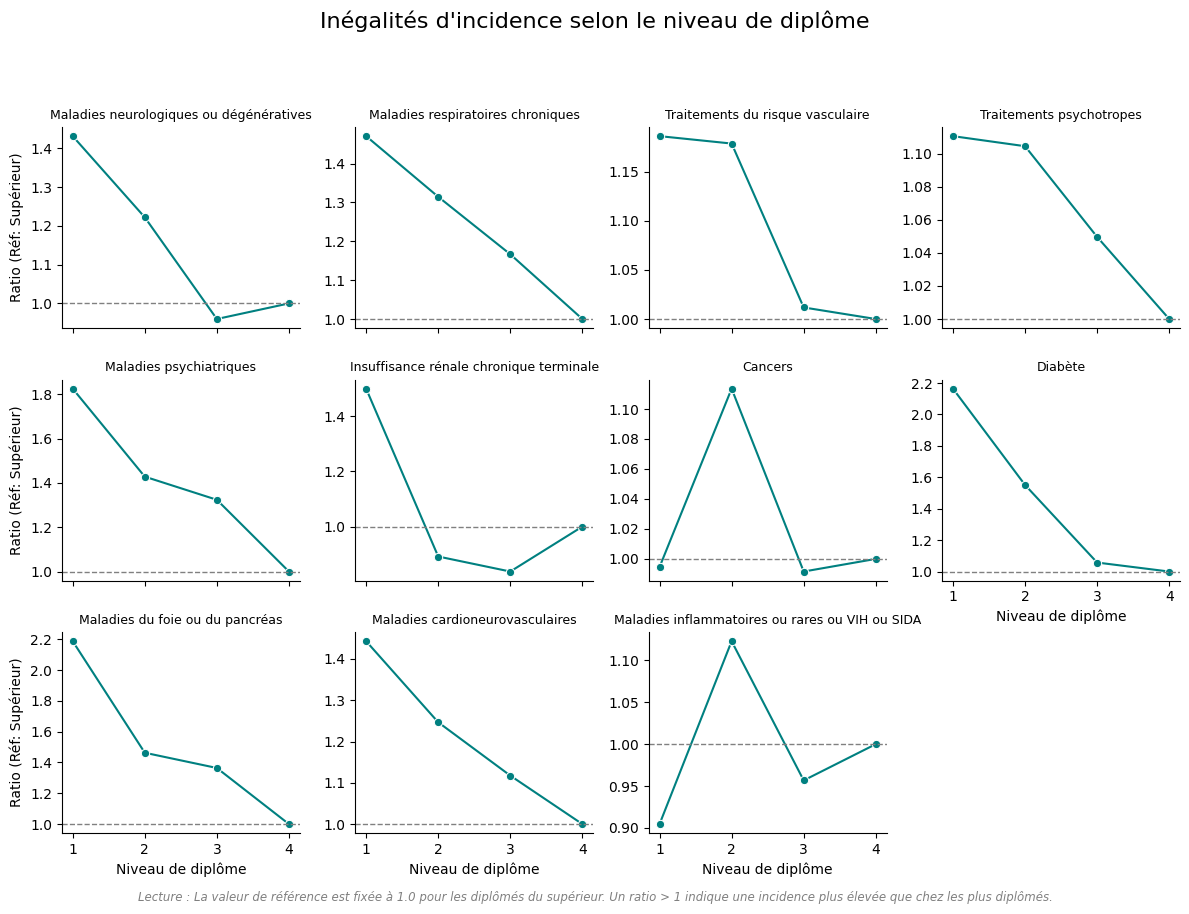

In [96]:
mask_dip = (df_maladies['I_cat'] == 1) & (df_maladies['varPartition'].isna()) & \
           (df_maladies['varGroupage'] == 'EAR_DIPLR_S') & \
           (df_maladies['type'] == 'incidence')

df_dip = df_maladies[mask_dip].copy()
df_dip['valGroupage'] = pd.to_numeric(df_dip['valGroupage'], errors='coerce')

df_dip_ratio = df_dip.groupby('catLib', group_keys=False).apply(calc_ratio_dip)

g_dip = sns.FacetGrid(df_dip_ratio, col="catLib", col_wrap=4, height=3, sharey=False)
g_dip.map(sns.lineplot, "valGroupage", "ratio_to_Sup", marker="o", color="teal")

# ← Extraction des libellés diplôme depuis la table de référence
labels_diplome = (
    libelles[libelles['varGroupage'] == 'EAR_DIPLR_S']
    .assign(val_num=lambda x: pd.to_numeric(x['valGroupage'], errors='coerce'))
    .dropna(subset=['val_num'])
    .set_index('val_num')['libelle']
    .to_dict()
)

g_dip.set_axis_labels("Niveau de diplôme", "Ratio (Réf: Supérieur)")
g_dip.set_titles(col_template="{col_name}", size=9)         # ← taille réduite
g_dip.refline(y=1, linestyle="--", color="gray", linewidth=1)  # ← ligne de référence

plt.subplots_adjust(top=0.85)
g_dip.fig.suptitle("Inégalités d'incidence selon le niveau de diplôme", fontsize=16)
g_dip.fig.text(
    0.5, -0.01,
    "Lecture : La valeur de référence est fixée à 1.0 pour les diplômés du supérieur. "
    "Un ratio > 1 indique une incidence plus élevée que chez les plus diplômés.",
    ha="center", fontsize=8.5, style="italic", color="gray"
)
plt.show()

La forte similarité entre les profils observés ici et ceux de la section 5.3 n'est pas surprenante : revenu et diplôme sont des déterminants sociaux étroitement corrélés. Cette colinéarité sera discutée dans les limites du modèle de régression (section 6.2).

### 5.5 Cartographie régionale des inégalités de prévalence

Cette série de cartes illustre l'intensité du gradient social de santé dans chaque région de France métropolitaine pour différentes pathologies.

**Indicateur — Ratio D1/D10 :** rapport entre le taux de prévalence des 10 % les plus modestes et celui des 10 % les plus aisés au sein de chaque région. Un ratio élevé (teinte sombre) indique une forte inégalité sociale locale ; un ratio proche de 1 (teinte claire) signale une pathologie qui frappe de façon plus uniforme les différentes classes sociales.

/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  re

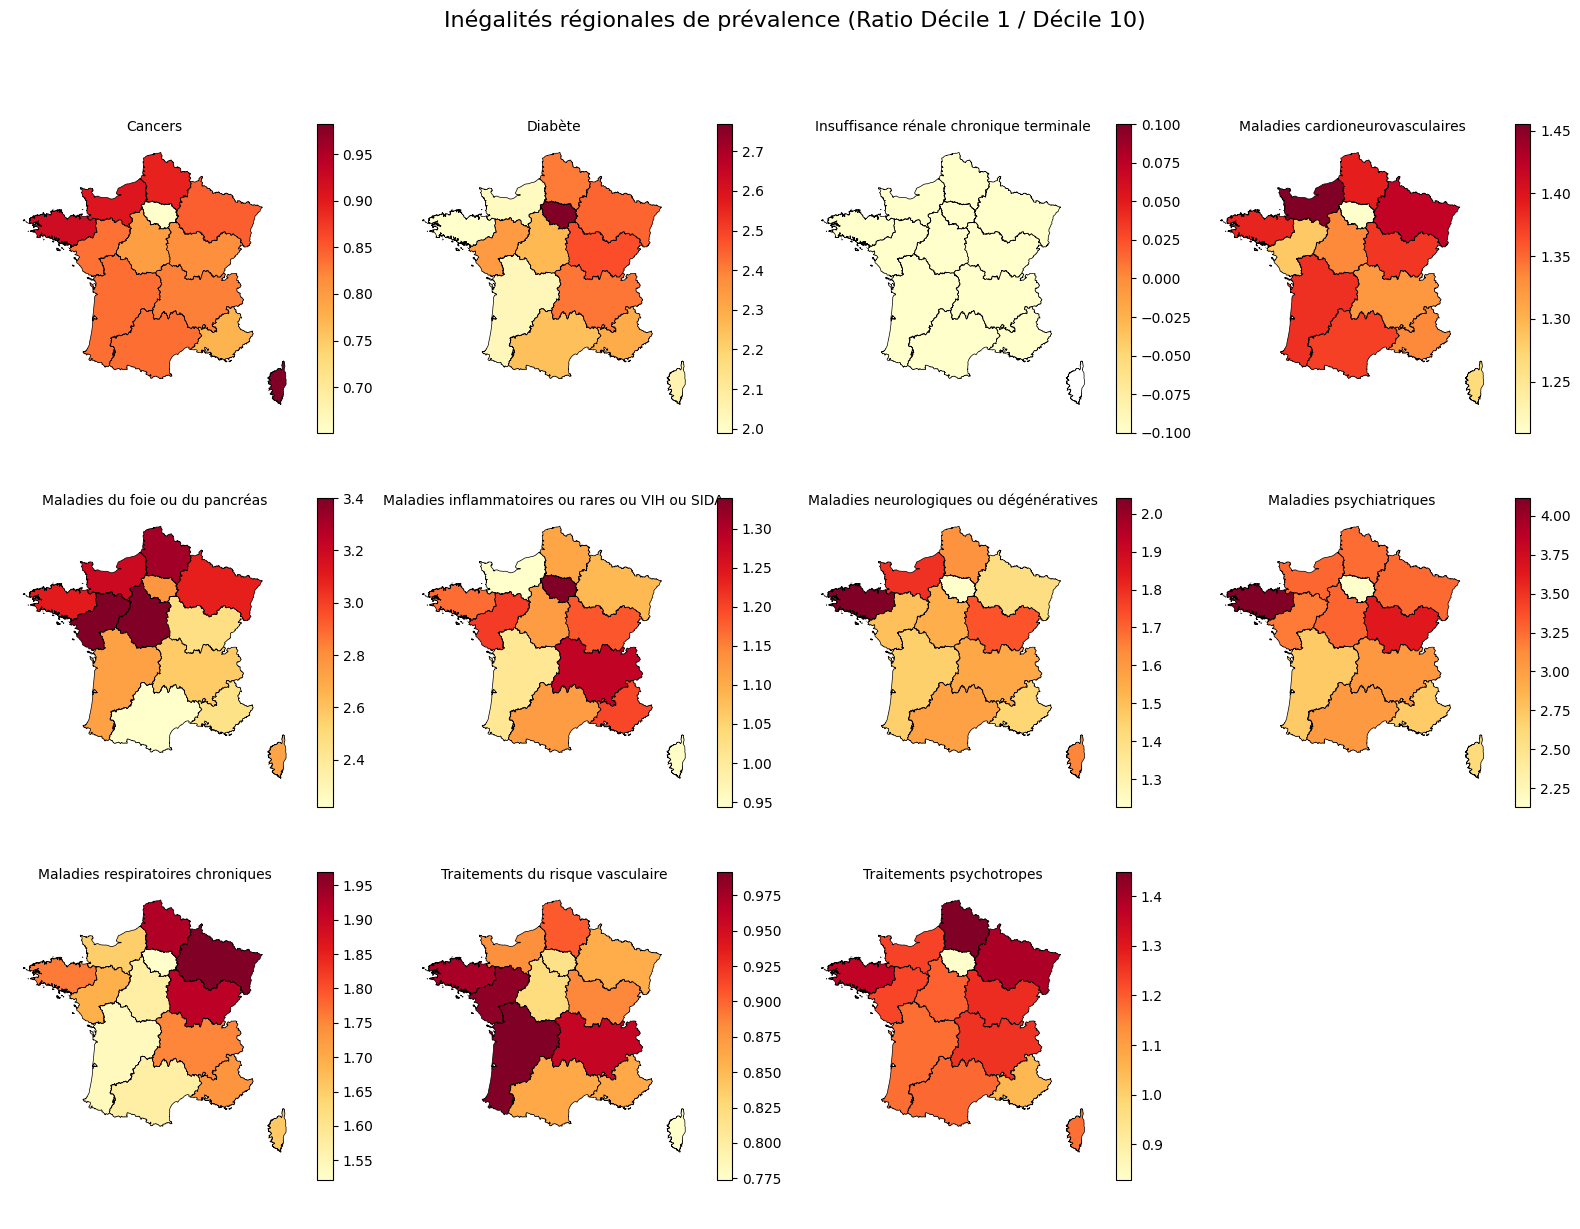

In [97]:
# Filtrage pour récupérer les données par région
mask_reg = (df_maladies['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') & \
           (df_maladies['varPartition'] == 'FISC_REG_S') & \
           (df_maladies['type'] == 'prevalence') & \
           (df_maladies['I_cat'] == 1)

df_reg = df_maladies[mask_reg].copy()

df_reg['valGroupage'] = pd.to_numeric(df_reg['valGroupage'], errors='coerce')

pivot_reg = df_reg.pivot_table(
    index=['valPartition', 'catLib'],
    columns='valGroupage',
    values='txStandDir'
)

assert 1 in pivot_reg.columns and 10 in pivot_reg.columns, \
    "Les déciles 1 et 10 sont absents du pivot — vérifier le type de valGroupage"

pivot_reg['ratio_D1_D10'] = pivot_reg[1] / pivot_reg[10]
pivot_reg = pivot_reg.rename(columns={1: 'D1', 10: 'D10'})
pivot_reg = pivot_reg.reset_index()
pivot_reg['valPartition'] = pivot_reg['valPartition'].astype(str)

url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions.geojson"
gdf_regions = gpd.read_file(url_geojson)

map_data = gdf_regions.merge(pivot_reg, left_on='code', right_on='valPartition', how='inner')

pathologies = map_data['catLib'].unique()
n_cols = 4
n_rows = (len(pathologies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, patho in enumerate(pathologies):
    ax = axes[i]
    data_patho = map_data[map_data['catLib'] == patho]
    data_patho.plot(column='ratio_D1_D10', ax=ax, legend=True,
                    cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                    legend_kwds={'shrink': 0.8})
    ax.set_title(patho, fontsize=10)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Inégalités régionales de prévalence (Ratio Décile 1 / Décile 10)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Plus la teinte est sombre (rouge), plus l'inégalité sociale est marquée. À l'inverse, une teinte claire indique une pathologie qui frappe de manière plus uniforme les différentes classes sociales du territoire.

Ces cartes permettent d'identifier des zones de vulnérabilité où la précarité "pèse plus lourd" sur la santé. Par exemple, une région peut présenter une forte prévalence globale mais une faible inégalité (ratio proche de 1), suggérant un système de soin local qui parvient mieux à protéger les populations les plus fragiles.

La valeur annotée sur chaque carte correspond à la région présentant le ratio D1/D10 le plus élevé pour cette pathologie. 

Les cartes révèlent une hétérogénéité géographique non négligeable : à pathologie identique, l'intensité du gradient social varie selon les régions, ce qui peut refléter des différences d'accès aux soins ou de structures économiques locales.

#### Carte bivariée

Les cartes précédentes montrent l'inégalité sociale région par région, mais ne permettent pas de croiser deux dimensions simultanément. La carte bivariée y remédie en combinant sur une même carte :
- **l'axe horizontal** : la prévalence absolue chez les plus modestes (D1)
- **l'axe vertical** : l'intensité de l'inégalité sociale (Ratio D1/D10)

Chaque variable est découpée en terciles (faible / moyen / élevé), formant une grille 3×3 de 9 combinaisons possibles. La légende miniature en bas à gauche de chaque carte indique la correspondance couleur / combinaison.

Les régions les plus préoccupantes sont celles en **haut à droite** de la grille : forte prévalence chez les modestes **et** forte inégalité sociale (teinte rouge/violette foncée). À l'inverse, une région en bas à gauche présente une faible prévalence et une faible inégalité.

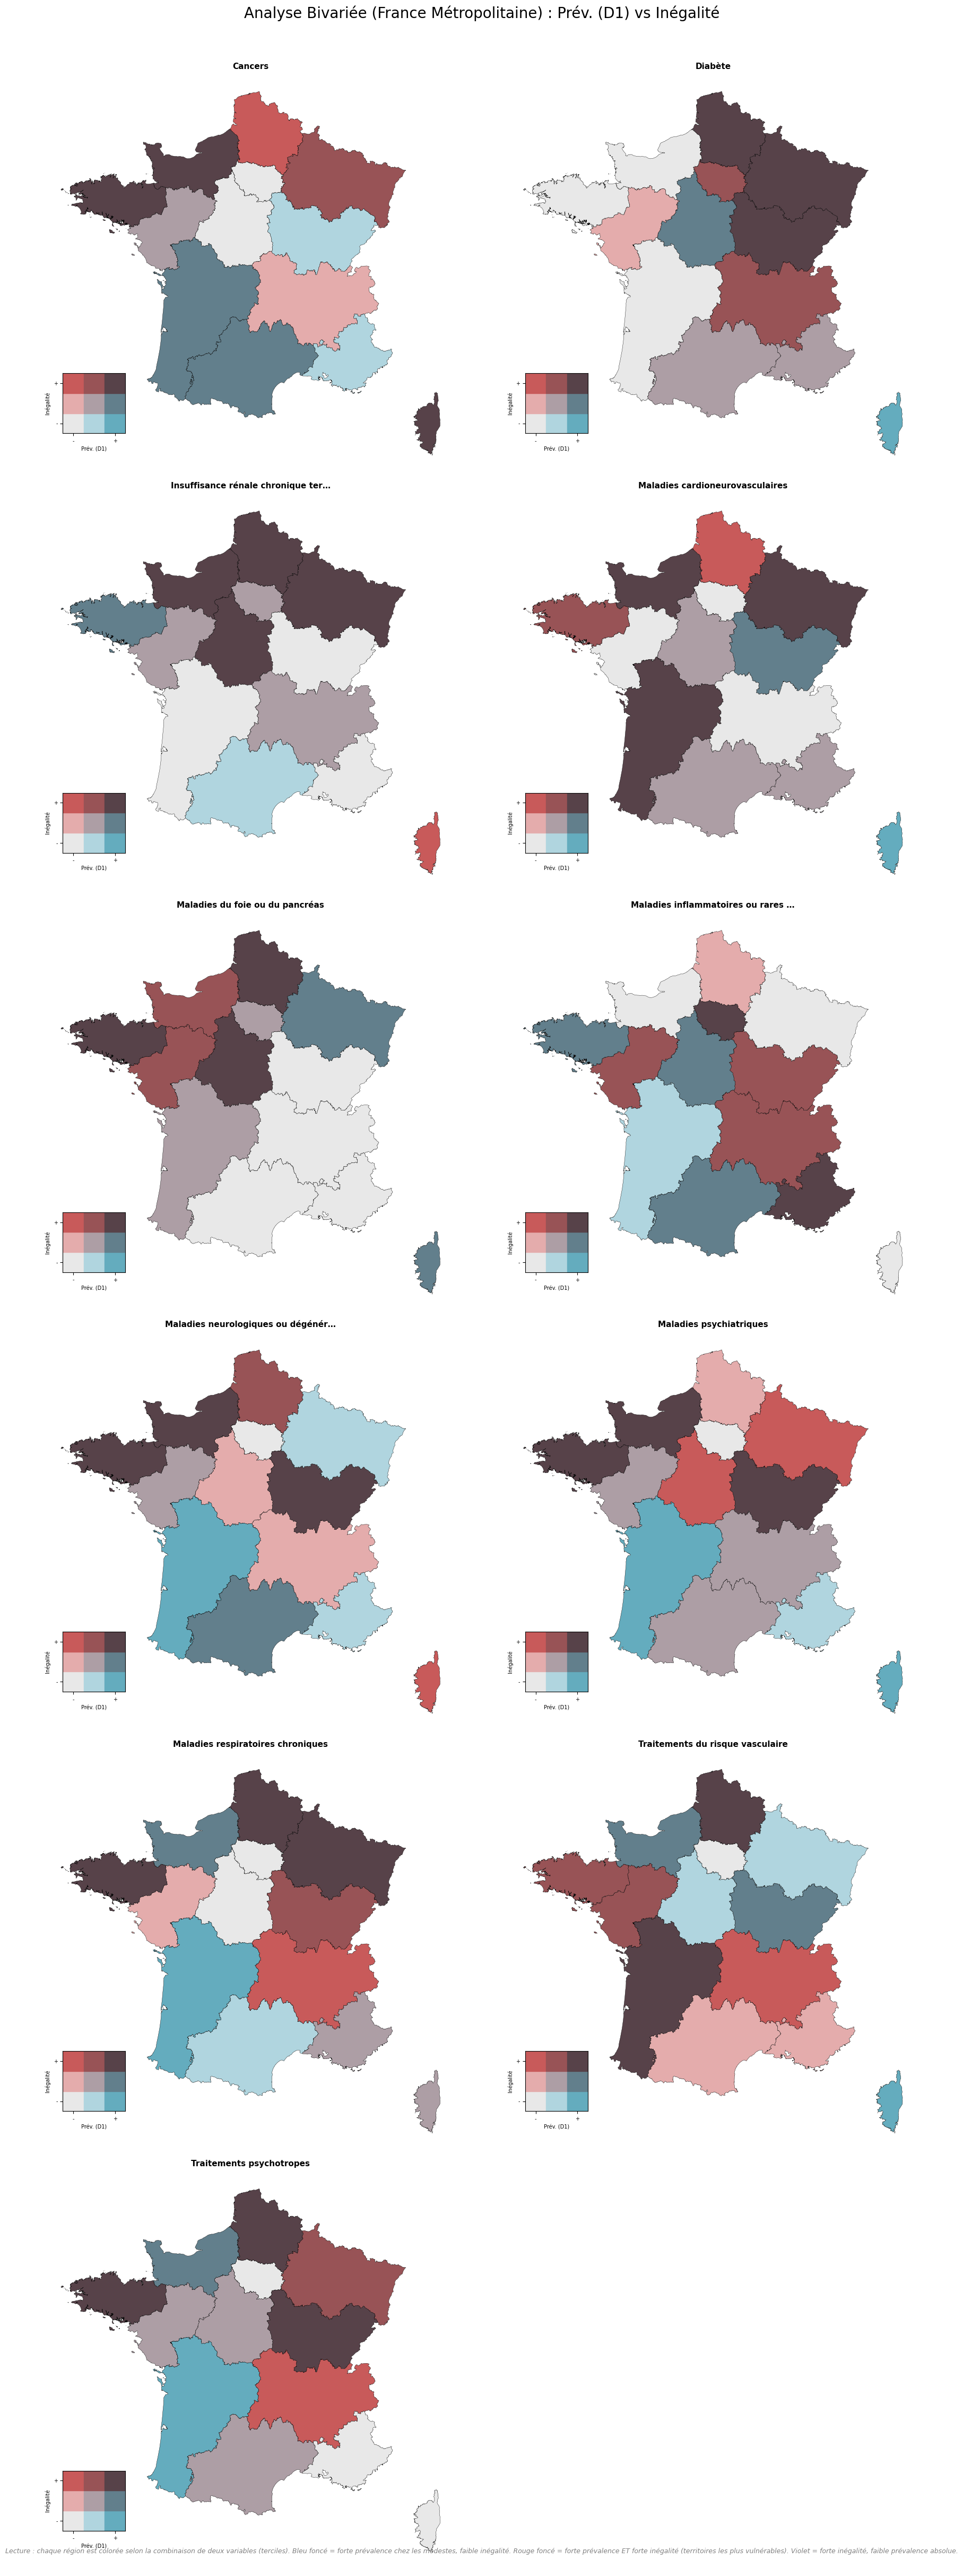

In [98]:
plot_bivariate_metropole(
    map_data, 
    'D1',               # Prévalence D1
    'ratio_D1_D10',     # Inégalité
    "Prév. (D1)", 
    "Inégalité"
)

Ces cartes permettent d'identifier les territoires qui cumulent à la fois une forte exposition des plus modestes et une forte inégalité sociale. Une région peut en effet présenter une prévalence élevée mais une faible inégalité (tous les groupes sociaux sont touchés de façon similaire), ou à l'inverse une faible prévalence globale mais un gradient social très marqué.

Ces résultats complètent les cartes choroplèthes simples et orientent les pistes d'approfondissement territorial évoquées en conclusion.

## 6. Modélisation

### 6.1 Clustering des pathologies selon leur profil d'inégalité sociale

L'objectif est de regrouper les maladies chroniques selon la forme de leur gradient social : certaines touchent davantage les plus modestes, d'autres les plus aisés, d'autres encore ne présentent pas de gradient marqué.

On construit pour cela une matrice où chaque ligne est une maladie et chaque colonne est un décile de revenu. Les valeurs sont les taux de prévalence standardisés.

On construit la matrice.

In [99]:
# On filtre sur la ventilation par décile de revenu, en prévalence uniquement,
# sans partition (vue nationale)
df_deciles = df_maladies[
    (df_maladies['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') &
    (df_maladies['type'] == 'prevalence') &
    (df_maladies['varPartition'].isna())
][['varTauxLib', 'valGroupage', 'txStandDir']].dropna()

# Pivot : 1 ligne par maladie, 1 colonne par décile
matrice = df_deciles.pivot_table(
    index='varTauxLib',
    columns='valGroupage',
    values='txStandDir'
)

# Suppression des maladies avec des valeurs manquantes
matrice = matrice.dropna()

print(f"Matrice : {matrice.shape[0]} maladies × {matrice.shape[1]} déciles")
matrice.head()


Matrice : 52 maladies × 10 déciles


valGroupage,1,10,2,3,4,5,6,7,8,9
varTauxLib,,,,,,,,,,
Accident vasculaire cérébral aigu,0.002120,0.001495,0.002157,0.002175,0.001965,0.001866,0.001776,0.001741,0.001634,0.001629
Artériopathie oblitérante du membre inférieur,0.012508,0.006624,0.013862,0.013435,0.012744,0.011775,0.011347,0.010691,0.009511,0.008464
Autres affections cardiovasculaires,0.006074,0.003976,0.006822,0.007187,0.006779,0.006425,0.005954,0.005550,0.005170,0.004567
Autres affections neurologiques,0.003313,0.001853,0.003286,0.003087,0.002702,0.002395,0.002316,0.002145,0.002018,0.001853
Autres maladies inflammatoires chroniques,0.002945,0.002616,0.003326,0.003212,0.003404,0.003237,0.003124,0.002967,0.002874,0.003019


On normalise car sans elle, les maladies très prévalentes (comme le diabète) domineraient le clustering juste par leur ordre de grandeur, indépendamment de la forme de leur gradient.

In [100]:
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(matrice)

#### Choix du nombre de clusters

On utilise deux méthodes complémentaires pour choisir le nombre de clusters :
- La **méthode du coude** (inertie en fonction de k)
- Le **score de silhouette** (qualité de la séparation des clusters)

##### Méthode du coude

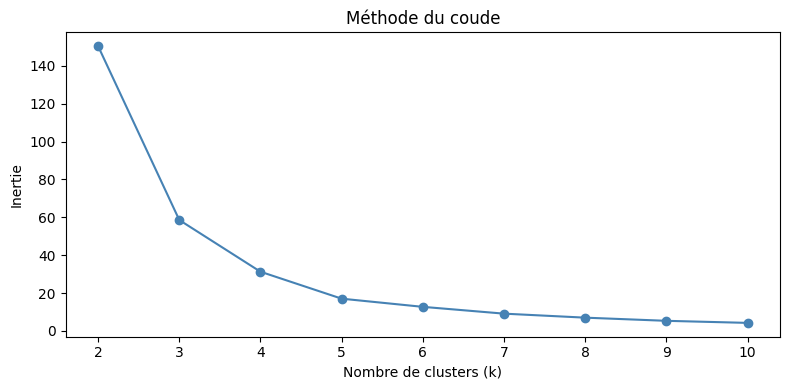

In [101]:
inerties = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(matrice_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inerties, marker='o', color='steelblue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.tight_layout()
plt.show()

D'après la méthode du coude, choisir 3 ou 4 clusters semble être une bonne solution. Pour nous aider à choisir, nous allons utiliser le score de silhouette.

##### Score de silhouette

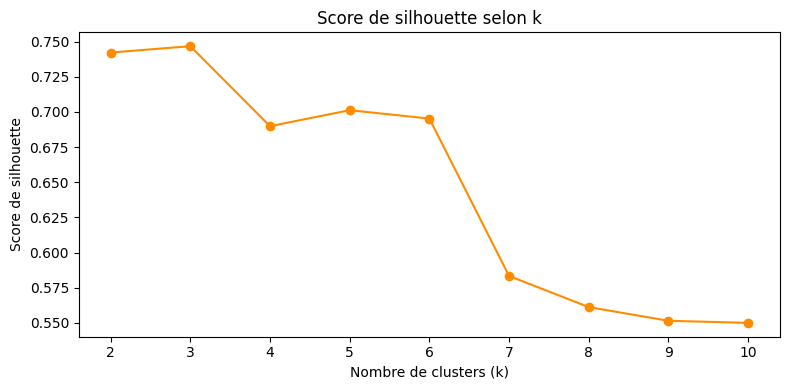

In [102]:
silhouettes = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(matrice_scaled)
    silhouettes.append(silhouette_score(matrice_scaled, labels_k))

plt.figure(figsize=(8, 4))
plt.plot(K, silhouettes, marker='o', color='darkorange')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon k")
plt.tight_layout()
plt.show()

In [103]:
# Identification automatique du meilleur k selon le score de silhouette
k_optimal_silhouette = K[silhouettes.index(max(silhouettes))]

print(f"Score de silhouette maximal : {max(silhouettes):.3f} → k optimal = {k_optimal_silhouette}")

Score de silhouette maximal : 0.747 → k optimal = 3


On va choisir le nombre de clusters qui permet de maximiser le score de silhouette. Ici, 3 permet de maximiser ce score. Comme d'après la méthode du coude, on hésitait entre 3 et 4 comme nombre de clusters optimal, on va donc retenir 3 clusters.

#### Modèle final

In [104]:
K_FINAL = 3

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
matrice['cluster'] = kmeans_final.fit_predict(matrice_scaled)

print("Répartition des maladies par cluster :")
print(matrice['cluster'].value_counts().sort_index())

Répartition des maladies par cluster :
cluster
0    41
1     9
2     2
Name: count, dtype: int64


#### Interprétation des clusters

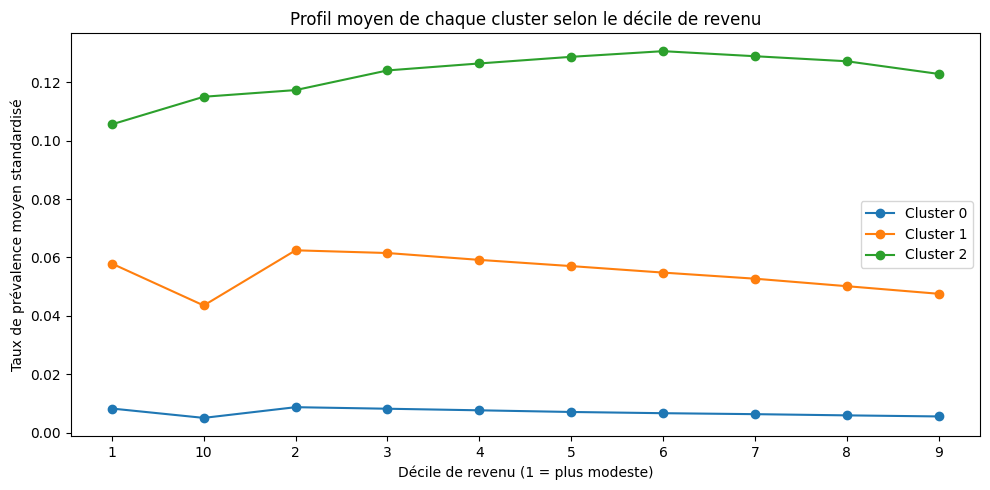

In [105]:
# Profil moyen de chaque cluster (taux par décile)
profils = matrice.groupby('cluster').mean()

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))

for cluster_id in profils.index:
    ax.plot(
        profils.columns.astype(str),
        profils.loc[cluster_id],
        marker='o',
        label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Décile de revenu (1 = plus modeste)")
ax.set_ylabel("Taux de prévalence moyen standardisé")
ax.set_title("Profil moyen de chaque cluster selon le décile de revenu")
ax.legend()
plt.tight_layout()
plt.show()

In [106]:
for c in sorted(matrice['cluster'].unique()):
    maladies = matrice[matrice['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(maladies)} maladies) :")
    for m in maladies:
        print(f"  - {m}")


Cluster 0 (41 maladies) :
  - Accident vasculaire cérébral aigu
  - Artériopathie oblitérante du membre inférieur
  - Autres affections cardiovasculaires
  - Autres affections neurologiques
  - Autres maladies inflammatoires chroniques
  - Autres troubles psychiatriques
  - Dialyse chronique
  - Déficience mentale
  - Démences (dont maladie d'Alzheimer)
  - Embolie pulmonaire aiguë
  - Hémophilie ou troubles de l'hémostase graves
  - Insuffisance cardiaque aiguë
  - Insuffisance cardiaque chronique
  - Insuffisance rénale chronique terminale
  - Maladie coronaire chronique
  - Maladie de Parkinson
  - Maladie valvulaire
  - Maladies du foie ou du pancréas
  - Maladies inflammatoires chroniques intestinales
  - Maladies inflammatoires ou rares ou VIH ou SIDA
  - Maladies métaboliques héréditaires ou amylose
  - Maladies neurologiques ou dégénératives
  - Mucoviscidose
  - Myopathie ou myasthénie
  - Paraplégie
  - Polyarthrite rhumatoïde et maladies apparentées
  - Sclérose en plaques


### 6.2 Régression : le décile de revenu prédit-il le taux de prévalence ?

On cherche à quantifier l'effet du niveau de vie sur le taux de prévalence des maladies chroniques. 

Chaque observation correspond à une combinaison (maladie × décile de revenu). La variable cible est le taux de prévalence standardisé (`txStandDir`). La variable explicative principale est le décile de revenu (variable numérique de 1 à 10). On ajoute des indicatrices par maladie pour contrôler les différences de prévalence de base entre pathologies.

**Question posée au modèle :**  À maladie donnée, une augmentation du décile de revenu est-elle associée à une diminution du taux de prévalence ?

#### Construction du dataset de régression

In [107]:
# Filtrage sur la ventilation par décile de revenu uniquement
df_reg = df_maladies[
    (df_maladies['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') &
    (df_maladies['type'] == 'prevalence') &
    (df_maladies['varPartition'].isna())
][['varTauxLib', 'valGroupage', 'txStandDir']].dropna()

# Conversion du décile en numérique
df_reg['decile'] = pd.to_numeric(df_reg['valGroupage'], errors='coerce')
df_reg = df_reg.dropna(subset=['decile'])

print(f"Dataset filtré : {df_reg.shape[0]} lignes × {df_reg.shape[1]} colonnes")
print(f"Maladies distinctes : {df_reg['varTauxLib'].nunique()}")
print(f"Déciles disponibles : {sorted(df_reg['decile'].unique())}")
df_reg.head(10)

Dataset filtré : 520 lignes × 4 colonnes
Maladies distinctes : 52
Déciles disponibles : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,varTauxLib,valGroupage,txStandDir,decile
342,Maladies du foie ou du pancréas,1,0.012865,1
343,Syndrome coronaire aigu,1,0.001581,1
344,Traitements antihypertenseurs,1,0.099411,1
345,Mucoviscidose,1,0.000105,1
346,Démences (dont maladie d'Alzheimer),1,0.012819,1
347,Troubles psychiatriques ayant débuté dans l'en...,1,0.003348,1
348,Traitements psychotropes,2,0.087329,2
349,Séquelle d'accident vasculaire cérébral,2,0.014450,2
350,Mucoviscidose,2,0.000119,2
351,Myopathie ou myasthénie,2,0.000755,2


#### Encodage des maladies

Les maladies sont des variables catégorielles. On les encode en indicatrices (one-hot encoding) afin que le modèle puisse contrôler les différences de prévalence de base entre pathologies — indépendamment du gradient social.

Par exemple, le cancer est moins prévalent que l'hypertension quelle que soit la catégorie sociale : sans ces indicatrices, cette différence de base biaiserait l'estimation de l'effet du décile.

In [108]:
# One-hot encoding des maladies
df_encoded = pd.get_dummies(
    df_reg[['varTauxLib', 'decile', 'txStandDir']],
    columns=['varTauxLib'],
    drop_first=True  # évite la multicolinéarité parfaite
)

FEATURES = [col for col in df_encoded.columns if col != 'txStandDir']
X = df_encoded[FEATURES]
y = df_encoded['txStandDir']

print(f"Observations : {len(X)}")
print(f"Nombre de features : {len(FEATURES)}")
print("  dont décile : 1 variable numérique")
print(f"  dont maladies : {len(FEATURES) - 1} indicatrices")

Observations : 520
Nombre de features : 52
  dont décile : 1 variable numérique
  dont maladies : 51 indicatrices


#### Entraînement du modèle avec validation croisée Leave-One-Out

Le dataset de régression est de petite taille (environ 10 observations par maladie, soit ~200 lignes au total après pivot). Dans ce contexte, une séparation train/test classique à 80/20 serait peu fiable : l'échantillon de test serait trop petit (~40 lignes) pour estimer correctement la performance.

On utilise à la place une **validation croisée Leave-One-Out (LOO)** : à chaque itération, une seule observation est mise de côté pour le test, et le modèle est entraîné sur toutes les autres. Cette méthode maximise l'utilisation des données et produit une estimation quasi-non-biaisée de l'erreur de généralisation.

**Métriques d'évaluation :**
- **R² (CV)** : part de variance expliquée, estimée par cross-validation
- **RMSE (CV)** : erreur quadratique moyenne en validation croisée, dans la même unité que `txStandDir`

In [109]:
model = LinearRegression()
loo = LeaveOneOut()

# Cross-validation LOO : scores R²
r2_scores = cross_val_score(model, X, y, cv=loo, scoring='r2')

# Prédictions LOO pour le graphique et le RMSE
y_pred_loo = cross_val_predict(model, X, y, cv=loo)

r2_cv   = r2_scores.mean()
rmse_cv = np.sqrt(np.mean((y - y_pred_loo) ** 2))

print(f"Validation croisée Leave-One-Out sur {len(X)} observations")
print(f"R²   (CV) : {r2_cv:.3f}  (écart-type : {r2_scores.std():.3f})")
print(f"RMSE (CV) : {rmse_cv:.4f}")

# Entraînement sur l'ensemble complet pour extraire les coefficients
model.fit(X, y)
y_pred = y_pred_loo  # on garde les prédictions LOO pour les graphiques

/opt/python/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg,

Validation croisée Leave-One-Out sur 520 observations
R²   (CV) : nan  (écart-type : nan)
RMSE (CV) : 0.0044


#### Interprétation des coefficients

On s'intéresse en priorité au coefficient associé à la variable `decile` —  c'est lui qui répond directement à notre problématique.

Les coefficients des indicatrices de maladies sont des variables de contrôle : ils ne sont pas interprétés individuellement.

In [110]:
# Extraction du coefficient du décile uniquement
coef_decile = model.coef_[FEATURES.index('decile')]

print(f"Coefficient du décile de revenu : {coef_decile:.6f}")
print()

if coef_decile < 0:
    print("→ Quand le décile augmente (revenu plus élevé), le taux de prévalence")
    print(f"  diminue en moyenne de {abs(coef_decile):.6f} par décile supplémentaire.")
    print("  Cela confirme que les maladies chroniques touchent davantage les plus modestes.")
else:
    print("→ Quand le décile augmente (revenu plus élevé), le taux de prévalence")
    print(f"  augmente en moyenne de {coef_decile:.6f} par décile supplémentaire.")
    print("  Cela suggère que certaines maladies touchent davantage les plus aisés.")

Coefficient du décile de revenu : -0.000612

→ Quand le décile augmente (revenu plus élevé), le taux de prévalence
  diminue en moyenne de 0.000612 par décile supplémentaire.
  Cela confirme que les maladies chroniques touchent davantage les plus modestes.


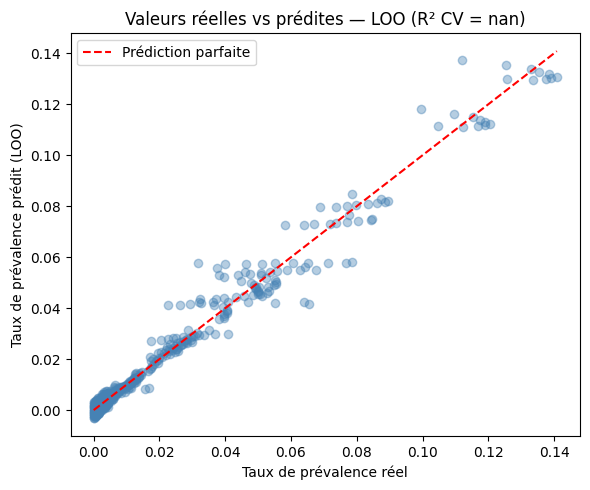

In [111]:
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred_loo, alpha=0.4, color='steelblue')
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--', label='Prédiction parfaite'
)
plt.xlabel("Taux de prévalence réel")
plt.ylabel("Taux de prévalence prédit (LOO)")
plt.title(f"Valeurs réelles vs prédites — LOO (R² CV = {r2_cv:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

#### Diagnostic des résidus

On vérifie que les résidus sont approximativement centrés en zéro et distribués normalement, ce qui valide les hypothèses de la régression linéaire.

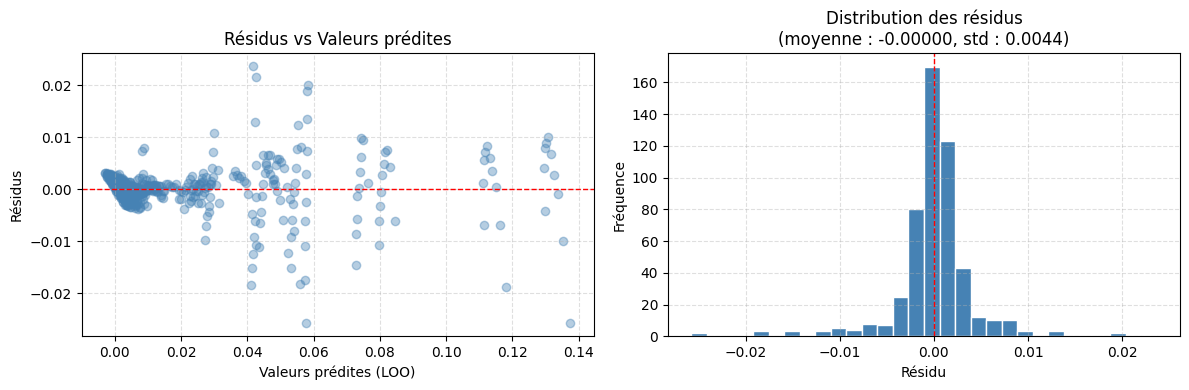

Résidu moyen   : -0.000001  (attendu ≈ 0)
Résidu max abs : 0.0258


In [112]:
residus = y - y_pred_loo

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Résidus vs valeurs prédites
axes[0].scatter(y_pred_loo, residus, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Valeurs prédites (LOO)")
axes[0].set_ylabel("Résidus")
axes[0].set_title("Résidus vs Valeurs prédites")
axes[0].grid(linestyle='--', alpha=0.4)

# Distribution des résidus
axes[1].hist(residus, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Résidu")
axes[1].set_ylabel("Fréquence")
axes[1].set_title(f"Distribution des résidus\n(moyenne : {residus.mean():.5f}, std : {residus.std():.4f})")
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Résidu moyen   : {residus.mean():.6f}  (attendu ≈ 0)")
print(f"Résidu max abs : {residus.abs().max():.4f}")

#### Interprétation des résidus

**Graphique 1 — Résidus vs Valeurs prédites**

On observe un **entonnoir net** : les résidus sont très resserrés autour de zéro pour les faibles valeurs prédites (maladies rares, taux proches de 0), puis s'écartent progressivement pour les valeurs prédites plus élevées. C'est un signe classique d'**hétéroscédasticité** : la variance des erreurs n'est pas constante, elle croît avec le niveau de prévalence.

Ce phénomène est cohérent avec la nature des données : les pathologies très prévalentes (maladies cardioneurovasculaires, diabète…) présentent naturellement une plus grande variabilité entre déciles, ce que le modèle linéaire ne capture pas entièrement.
On note également quelques résidus négatifs importants pour les valeurs prédites élevées (> 0.08), ce qui suggère que le modèle **surestime** le taux de prévalence de certaines pathologies fréquentes.

**Graphique 2 — Distribution des résidus**


La distribution est **centrée en zéro**, le modèle n'est pas systématiquement biaisé, il ne sur-estime ni ne sous-estime globalement

En revanche, la distribution présente un pic très étroit et prononcé autour de 0, avec des queues plus épaisses qu'une gaussienne. Cela traduit le fait que la majorité des erreurs sont très faibles (le modèle fonctionne bien sur les maladies rares et peu prévalentes), mais qu'un sous-ensemble de pathologies génère des erreurs plus grandes, tirant les queues de la distribution.

**Conclusion**

L'hétéroscédasticité et les queues épaisses indiquent que les hypothèses strictes de la
régression linéaire classique ne sont pas parfaitement vérifiées. Concrètement :

- Le **signe et l'ordre de grandeur du coefficient** du décile de revenu restent interprétables
  et fiables : le gradient social négatif est bien capturé.
- En revanche, les **p-values et intervalles de confiance** produits par OLS sont à prendre
  avec prudence, car ils supposent une variance constante des erreurs.
- Une piste d'amélioration serait d'appliquer une **transformation logarithmique** sur
  `txStandDir` (les taux de prévalence suivent souvent une distribution log-normale) ou
  d'utiliser une **régression WLS** (moindres carrés pondérés), en pondérant chaque
  observation par l'inverse de sa variance.

#### Limites du modèle

- **Faible nombre d'observations** : le dataset après pivot contient une ligne par maladie, ce qui limite la puissance statistique. Les résultats sont à interpréter avec prudence.
- **Analyse écologique** : on travaille sur des taux agrégés par groupe social, pas sur des données individuelles. On ne peut pas conclure qu'un individu appartenant à tel groupe aura tel taux de prévalence.
- **Colinéarité possible** : les trois variables explicatives (revenu, diplôme, CSP) sont corrélées entre elles dans la réalité sociale — un cadre est généralement aussi diplômé et à revenu élevé. Cette colinéarité peut rendre les coefficients individuels moins stables.

## Conclusion

Ce notebook avait pour objectif d'analyser les inégalités sociales face aux maladies chroniques en France à partir des données DREES (ER 1243), en répondant à la problématique suivante : *dans quelle mesure le niveau de vie détermine-t-il l'exposition aux maladies chroniques, et ce gradient varie-t-il selon les pathologies et les territoires ?*

### Ce que les données nous apprennent

**Un gradient social robuste et généralisé.** Les visualisations montrent de façon cohérente que les personnes appartenant aux déciles de revenu les plus bas présentent des taux d'incidence et de prévalence plus élevés pour la quasi-totalité des pathologies étudiées. Ce résultat est confirmé par la régression linéaire, dont le coefficient négatif associé au décile de revenu indique qu'une progression dans l'échelle des revenus est associée à une diminution du taux de prévalence standardisé.

**Des pathologies aux profils d'inégalité hétérogènes.** Le clustering K-Means a permis d'identifier des groupes de maladies selon la forme de leur gradient social. Certaines pathologies (maladies respiratoires, troubles psychiques) présentent un gradient très marqué en faveur des plus aisés ; d'autres (certains cancers) affichent un profil inverse ou peu différencié selon le revenu, ce qui suggère que d'autres déterminants entrent en jeu.

**Une dimension territoriale à ne pas négliger.** Les cartes régionales du ratio D1/D10 révèlent une hétérogénéité géographique : à pathologie identique, l'intensité du gradient social varie selon les régions, ce qui peut refléter des différences d'accès aux soins, de structures économiques locales ou de comportements de recours.

**L'effet du diplôme confirme celui du revenu.** Les graphiques par niveau de diplôme montrent un gradient similaire à celui observé par décile de revenu, ce qui est cohérent avec la forte corrélation entre ces deux déterminants sociaux.

### Limites et perspectives

- **Analyse écologique** : les données sont agrégées par groupe social ; on ne peut pas conclure à l'échelle individuelle (biais écologique).
- **Colinéarité des déterminants** : revenu, diplôme et CSP sont corrélés entre eux, ce qui rend difficile l'attribution causale à l'un ou l'autre facteur.
- **Absence de dimension temporelle** : les données sont une photographie à un instant donné ; une analyse longitudinale permettrait d'étudier l'évolution des inégalités dans le temps.
- **Pistes d'approfondissement** : intégrer les données de renoncement aux soins, croiser avec des indicateurs de densité médicale, ou modéliser les interactions entre déterminants via une régression multiple incluant revenu, diplôme et région.